In [3]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import xarray as xr
import geopandas as gpd
import rioxarray
import xcdat as xc
import seaborn as sns
import unityandnormal as u_n
import os
from datetime import timedelta
import warnings  
warnings.filterwarnings("ignore")
from pyextremes import EVA
from pyextremes import plot_threshold_stability
import DataAndCorr as DC
from pathlib import Path


In [2]:
# P_grid = xr.open_dataset("Data/Rijn_up_prec.nc")
# P = P_grid.spatial.average('rr', axis=["X", "Y"])
# P = P.bounds.add_missing_bounds()

# T_grid = xr.open_dataset("Data/Rijn_up_temp.nc")
# T = T_grid.spatial.average('tg', axis=["X", "Y"])
# T = T.bounds.add_missing_bounds()

In [3]:
# df = DC.combineQ_P_T(P,T,"Data/Discharges/Rijn")

# df.to_pickle("Data/RijnData.pkl")

In [4]:
df = pd.read_pickle("Data/RijnData.pkl").drop(columns=['1','P', 'T', '2'])
df_moisture = pd.read_pickle("Data/Pickles/6135055.pkl")
# print(df_snow)
df = df.merge(df_moisture, left_index=True, right_index=True)
# print(df)
# df = df[['0','P', 'T', '1', '2','M','Q']]
print(df.columns.to_list())

['0', 'P', 'T', 'M', 'R', 'Q']


<Axes: xlabel='time'>

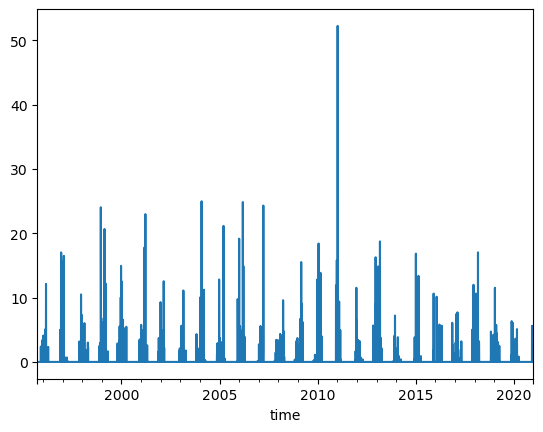

In [5]:
df["M"].plot()

In [4]:
# df_lags, df_extremes = DC.lagcheck(df,"Name", "0", 4000, "48h")

def makeLaggedArrays(df, lag):
    Qs = []
    maxes = []
    for lagname in df.columns.to_list():
        lags, maxvals= DC.lagcheck(df,"Name", lagname, 2970, "15d",lag)
        lags.dropna(inplace=True)
        Qs.append(lags)
        maxes.append(maxvals)
        # print(lags.shape)
        # plt.figure()
        # pd.plotting.autocorrelation_plot(lags.iloc[:,0])
        # plt.title("Q_Mainz")

    rain = Qs[1]
    rainacc = rain.cumsum(axis=1)
    # print(rainacc)
    Qs[1] = rainacc

    moist = Qs[4]
    moistacc = moist.cumsum(axis=1)
    # print(rainacc)
    Qs[4] = moistacc
    # print(rainacc, Qs[1], Qs)
    return Qs, maxes


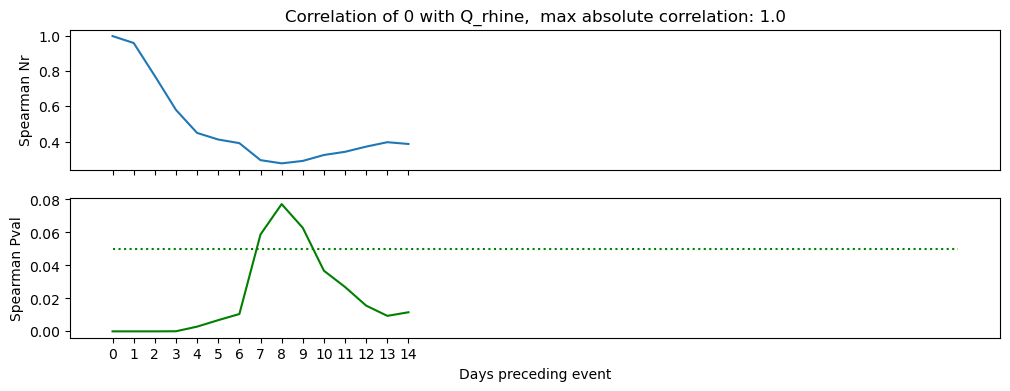

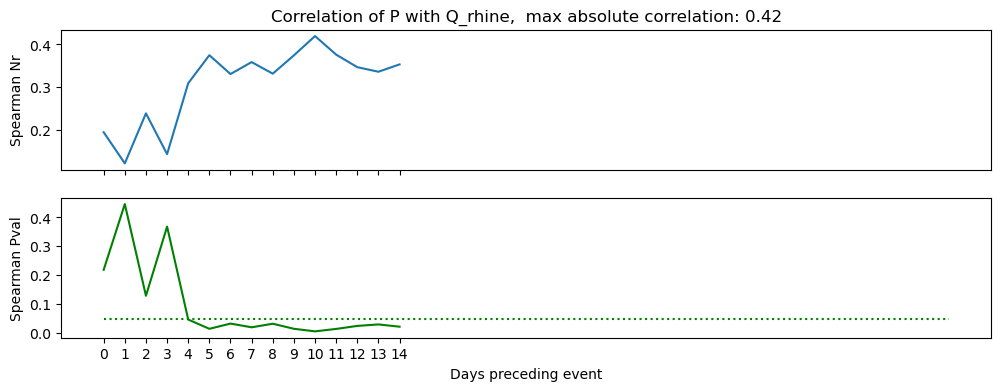

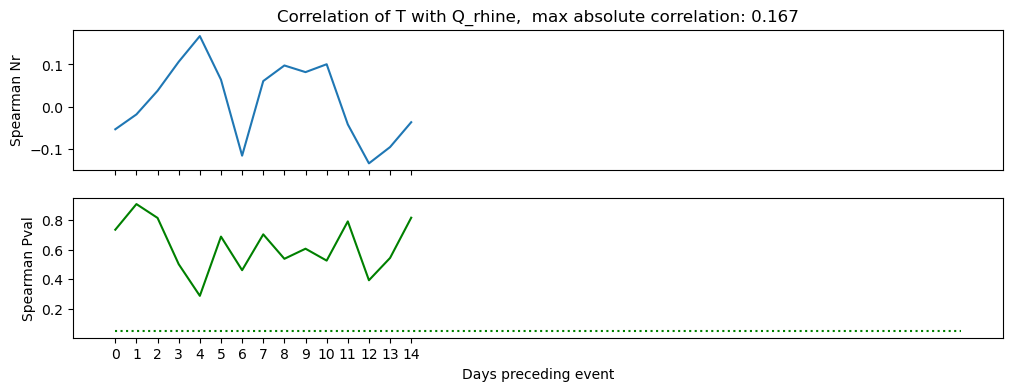

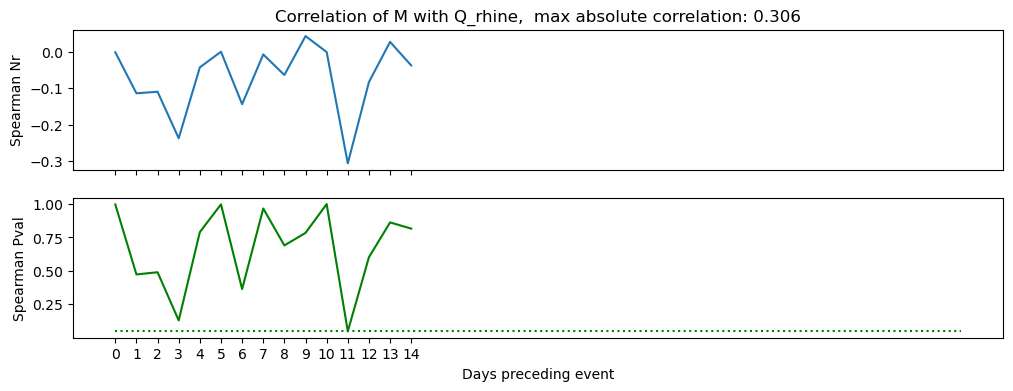

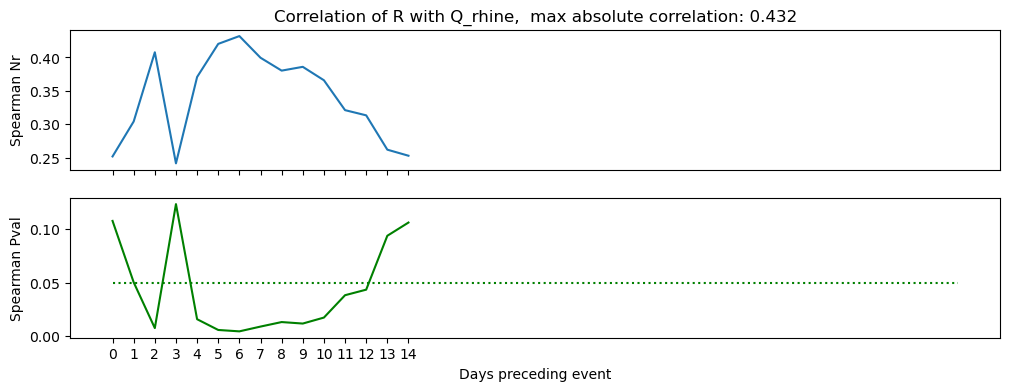

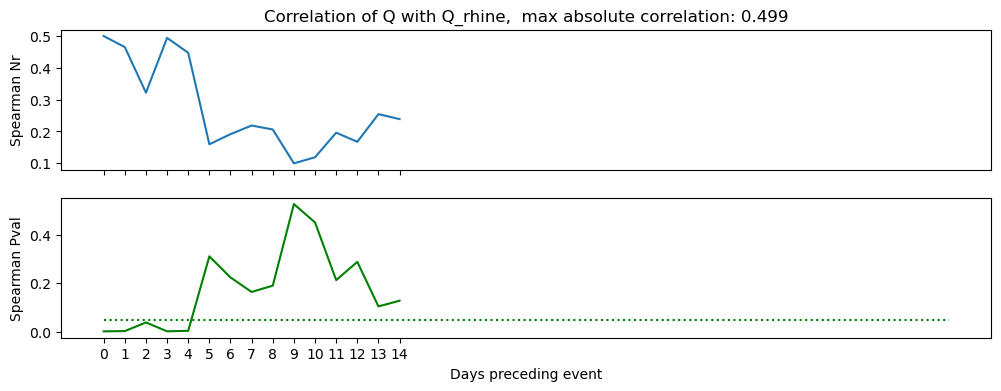

In [ ]:
for Q,name in zip(Qs[:], df.columns.to_list()):
    Q["Ref"] = Qs[0].iloc[:,0]
    col = Q.pop("Ref")
    Q.insert(0, col.name, col)

    corrmat = Q.corr(method='spearman')
    # print(corrmat)
    corrmat = corrmat.iloc[1:,0]
    pvals = Q.corr(method=DC.spearmanr_pval)
    pvals = pvals.iloc[1:,0]
    # f, axs = plt.subplots(2,1, sharex=True)

    # axs[0].set_title(f"Correlation of {name} with Q_rhine,  max absolute correlation: {np.round(max(abs(corrmat)),3)}")
    # axs[0].plot(corrmat)
    # axs[0].set_ylabel("Spearman Nr", fontsize="10")
    # axs[0].figure.set_size_inches(12, 4)
    # # axs[0].set_ylim((0.2,1))
    # axs[1].plot(pvals, color='green')
    # axs[1].hlines(0.05, 0,40, linestyle = 'dotted', color='green')
    # axs[1].set_ylabel("Spearman Pval", fontsize="10")
    # axs[1].set_xlabel("Days preceding event", fontsize="10")
    # f.savefig(f"Figures/LagCorr_{name}.png")


In [5]:
import re
import glob

def extract_lat_lon(filepath):
    """Read a file and extract latitude, longitude, catchment area (A),
    and altitude (H) from lines like:
    # Latitude (DD):       47.717634968
    # Longitude (DD):      7.306626878
    # Catchment area (km²):      666.0
    # Altitude (m ASL):        242.78
    """
    lat, lon, area, alt = None, None, None, None
    lat_pattern = re.compile(r'#\s*Latitude\s*\(DD\):\s*([-+]?\d*\.?\d+)')
    lon_pattern = re.compile(r'#\s*Longitude\s*\(DD\):\s*([-+]?\d*\.?\d+)')
    area_pattern = re.compile(r'#\s*Catchment area\s*\(km²\):\s*([-+]?\d*\.?\d+)')
    alt_pattern = re.compile(r'#\s*Altitude\s*\(m ASL\):\s*([-+]?\d*\.?\d+)')

    with open(filepath, 'r', encoding='latin-1') as f:
        for line in f:
            lat_match = lat_pattern.search(line)
            if lat_match:
                lat = float(lat_match.group(1))
            lon_match = lon_pattern.search(line)
            if lon_match:
                lon = float(lon_match.group(1))
            area_match = area_pattern.search(line)
            if area_match:
                area = float(area_match.group(1))
            alt_match = alt_pattern.search(line)
            if alt_match:
                alt = float(alt_match.group(1))
            if lat is not None and lon is not None and area is not None and alt is not None:
                break

    return lat, lon, area, alt


def build_lat_lon_dataframe(numbers, folder='.'):
    """
    numbers: list of numbers (int or str) that the target filenames start with
    folder: directory containing the txt files
    """
    records = {}

    for num in numbers:
        pattern = os.path.join(folder, f"{num}*.txt")
        matches = glob.glob(pattern)

        if not matches:
            print(f"Warning: no file found for number {num}")
            continue
        if len(matches) > 1:
            print(f"Warning: multiple files found for number {num}, using first: {matches[0]}")

        filepath = matches[0]
        lat, lon, area, alt = extract_lat_lon(filepath)

        if lat is None or lon is None:
            print(f"Warning: could not find lat/lon in {filepath}")
        if area is None:
            print(f"Warning: could not find catchment area in {filepath}")
        if alt is None:
            print(f"Warning: could not find altitude in {filepath}")

        records[num] = {'latitude': lat, 'longitude': lon, 'A': area, 'H': alt}

    df = pd.DataFrame.from_dict(records, orient='index')
    df.index.name = 'number'
    return df
def selectForAnalysis(df, Qs, maxes,  window=30):

    dfselected = pd.DataFrame(df.loc[maxes[0].index])
    rainlag = Qs[1].iloc[:,window]

    dfselected['P'] = rainlag.values

    templag = pd.DataFrame(df['T'].loc[maxes[0].index-timedelta(days=0)].values, columns=['1'])

    for i in range(1,window):
        templag[str(i)] = df['T'].loc[maxes[0].index-timedelta(days=i)].values

    dfselected['T'] = templag.mean(axis=1).values
    snowlag = pd.DataFrame(df['M'].loc[maxes[0].index-timedelta(days=0)].values, columns=['1'])
#
    for i in range(1,window):
        snowlag[str(i)] = df['M'].loc[maxes[0].index-timedelta(days=i)].values

    dfselected['M'] = snowlag.mean(axis=1).values

    moisture = pd.DataFrame(df['Q'].loc[maxes[0].index-timedelta(days=0)].values, columns=['1'])
    #
    for i in range(1,window):
        moisture[str(i)] = df['Q'].loc[maxes[0].index-timedelta(days=i)].values

    dfselected['Q'] = moisture.mean(axis=1).values

    return dfselected

In [6]:
def find_shx_files(folder):
    folder = Path(folder)
    return [str(f) for f in folder.glob("*.pkl")]

In [7]:

pickles = find_shx_files("Data/Pickles")
corrlist = []
picklelist = []
df_0 = pd.read_pickle("Data/RijnData.pkl").drop(columns=['1','P', 'T', '2'])


for pickle in pickles:
    #read the pickle to df:
    df_moisture = pd.read_pickle(f"{pickle}")
    df = df_0.merge(df_moisture, left_index=True, right_index=True)
    if df["P"].isna().all():
        print(pickle[-11:-4], "is a bad pickle :( ")
        continue
    Qs, maxes = makeLaggedArrays(df, 16)
    dfselected = selectForAnalysis(df, Qs, maxes, 15)
    corrmat = DC.matrixplot(dfselected, f"Max discharge events at downstream station")
    
    corrlist.append(corrmat[:-1,-1])
    picklelist.append(pickle[-11:-4])
    

6335040 is a bad pickle :( 
6335075 is a bad pickle :( 
6335076 is a bad pickle :( 
6335113 is a bad pickle :( 
6335115 is a bad pickle :( 
6335116 is a bad pickle :( 
6335117 is a bad pickle :( 
6335349 is a bad pickle :( 
6335350 is a bad pickle :( 
6335351 is a bad pickle :( 


In [ ]:
corrdf = pd.DataFrame(np.array(corrlist), columns=["0", "P", "T", "M", "R"], index=picklelist)

corrdf = corrdf.sort_values(by=["M"])

# Example usage:
numbers = corrdf.index  # replace with your actual list
df = build_lat_lon_dataframe(numbers, folder="C:/Users/nunoh/Desktop/THESIS/OriginalData/gaugesRhine")  # adjust folder path
corrdf = pd.concat([corrdf,df], axis=1)
corrdf.to_pickle("Data/GaugeCorrs.pkl")

                0         P         T         M         R   latitude  \
6235300  0.145351  0.818424  0.487639 -0.324836 -0.021328  47.463333   
6235200  0.140270  0.767814  0.782636 -0.323425 -0.163218  47.257500   
6335451  0.625788  0.705217  0.341739 -0.281225  0.226087  47.672900   
6935411  0.601691  0.727253  0.523026 -0.144321 -0.310345  47.484600   
6935403  0.491444  0.798246  0.722807 -0.140598 -0.070175  47.358000   
...           ...       ...       ...       ...       ...        ...   
6935019  0.046927  0.747840  0.702983  0.576304 -0.269018  46.745740   
6335620  0.401872  0.321364 -0.361145  0.585314  0.026037  49.345874   
6935541 -0.019984  0.701048  0.615255  0.625668 -0.312755  46.858000   
6335540  0.292603  0.357099 -0.176132  0.642973  0.248922  50.181522   
6935530  0.124887  0.698261  0.809918  0.741107 -0.296148  46.631300   

         longitude  
6235300   9.681944  
6235200   9.729200  
6335451   9.601800  
6935411   9.327100  
6935403   9.081500  
...      

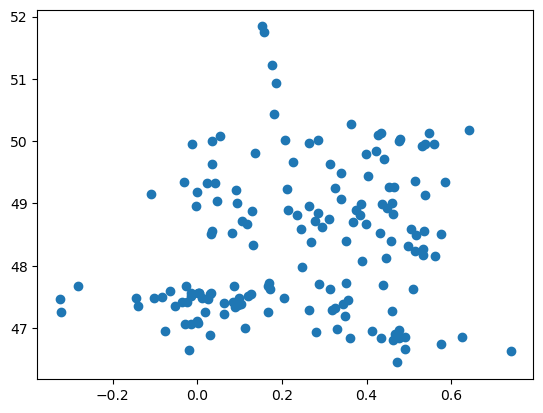

In [20]:
plt.scatter(corrdf["M"], corrdf["latitude"])
# plt.xlabel("Correlation between Gauge and Rhine")
# plt.ylabel("Correlation between Gauge and Soil Saturation")
# plt.plot(corrdf.sort_values(by=["0"])["0"])
# plt.plot(corrdf.sort_values(by=["0"])["R"])

# plt.hist(corrdf["M"], bins=50)
# plt.figure()
# plt.hist(corrdf["R"], bins=50)
# plt.figure()
# plt.hist(corrdf["0"], bins = 50)
# plt.figure()
# plt.hist(corrdf["T"], bins = 50)
# plt.legend()
print(corrdf)

In [14]:
import matplotlib as mpl

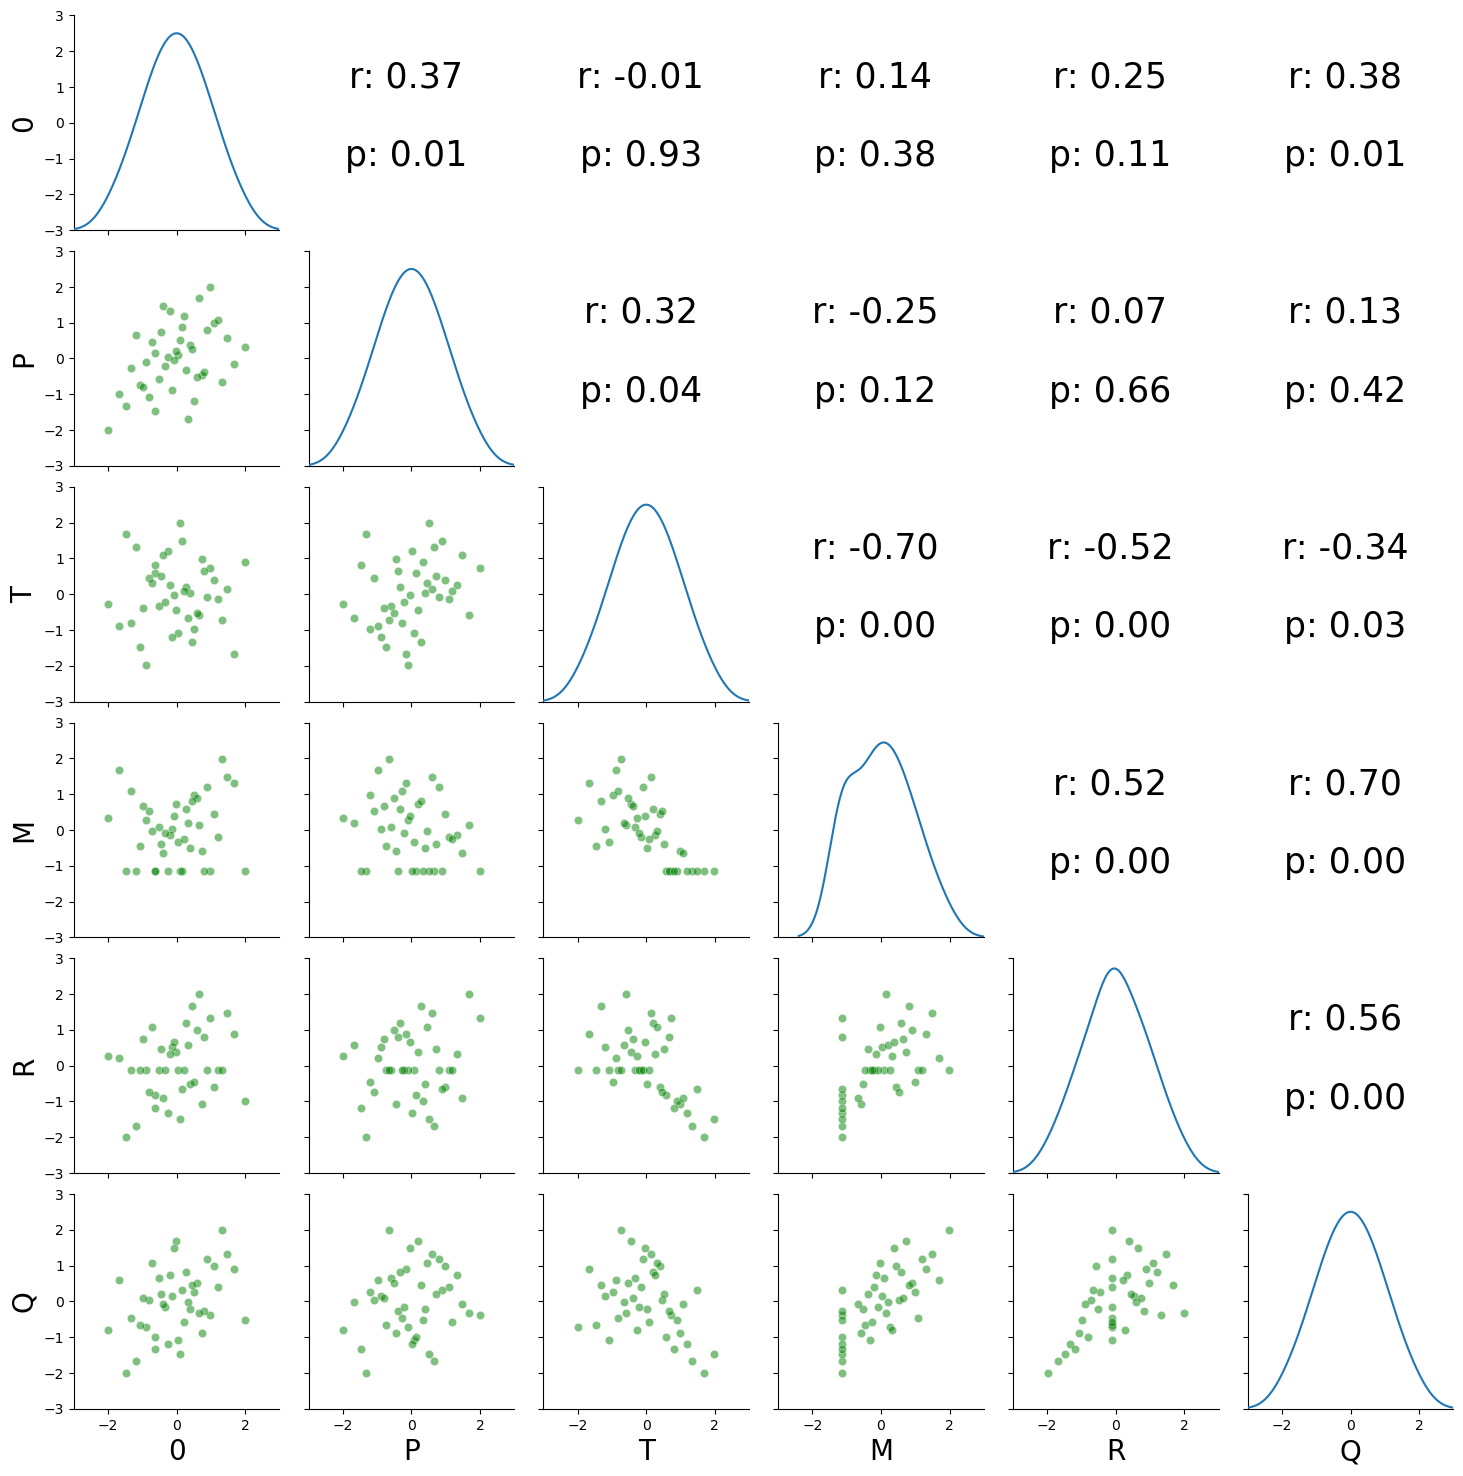

In [15]:
def reg_coef(x,y,label=None,color=None,**kwargs):
    ax = plt.gca()
    r,p = stats.spearmanr(x,y)
    ax.annotate(f'r: {r:.2f} \n\np: {p:.2f} ', xy=(0.5,0.3), xycoords='axes fraction', ha='center', size=25)
    ax.set_axis_off()

iris = u_n.sd_normal(dfselected).dropna()

mpl.rcParams["axes.labelsize"] = 20

g = sns.PairGrid(iris)
g.map_upper(reg_coef)
g.map_diag(sns.kdeplot)
g.map_lower(sns.scatterplot, alpha=0.5, color='green')
g.set(xlim=(-3,3), ylim=(-3,3))
g.savefig("RhinePairplot.png")



plt.show()

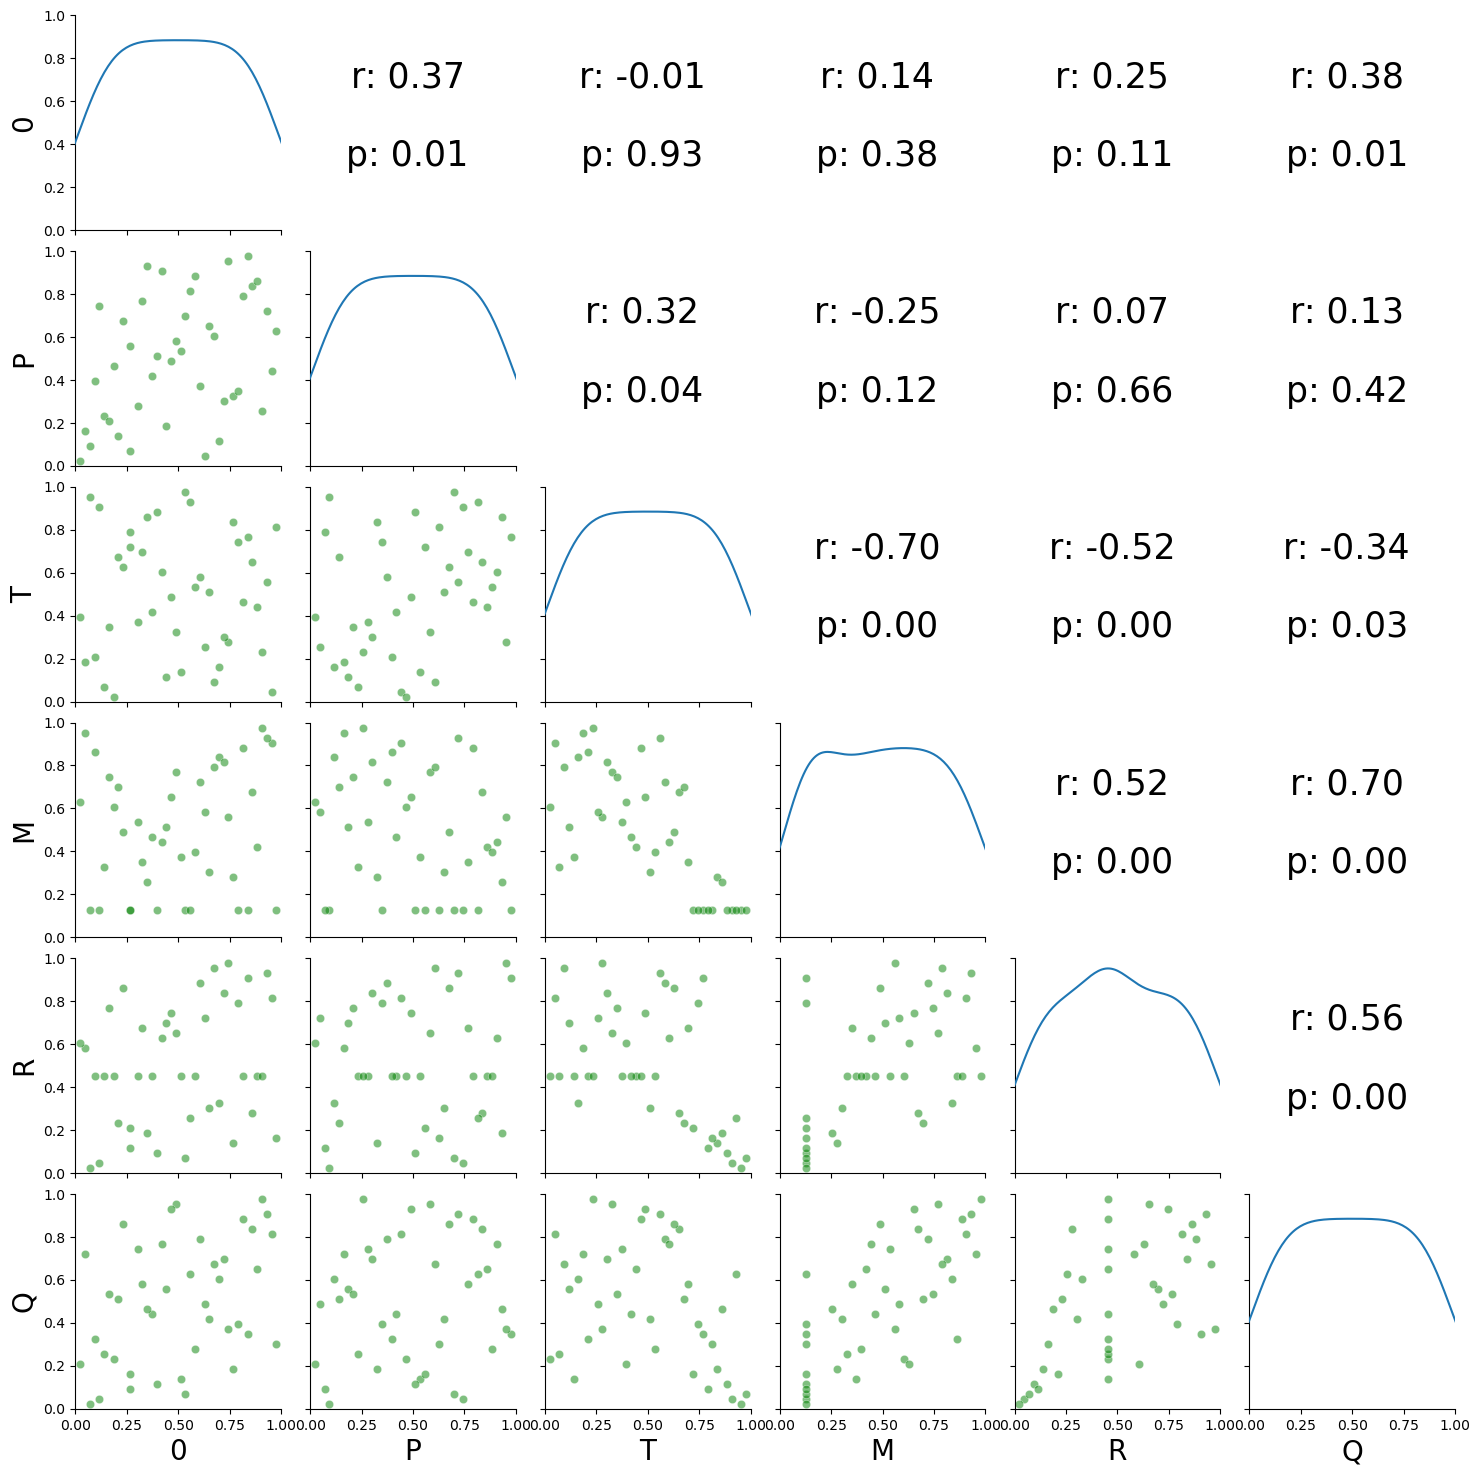

In [16]:
iris = u_n.unity(dfselected).dropna()

mpl.rcParams["axes.labelsize"] = 20

g = sns.PairGrid(iris)
g.map_upper(reg_coef)
g.map_diag(sns.kdeplot)
g.map_lower(sns.scatterplot, alpha=0.5, color='green')
g.set(xlim=(0,1), ylim=(0,1))
# g.savefig("DueroPairplot.png")



plt.show()
